In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
#load the dataset
data = pd.read_csv('knn_regression_dataset.csv')
data.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [5]:
#understand the dataset
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


In [6]:
#handle missing values
data.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [7]:
#drop rows with missing values
data = data.dropna()

In [8]:
data.isnull().sum()

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

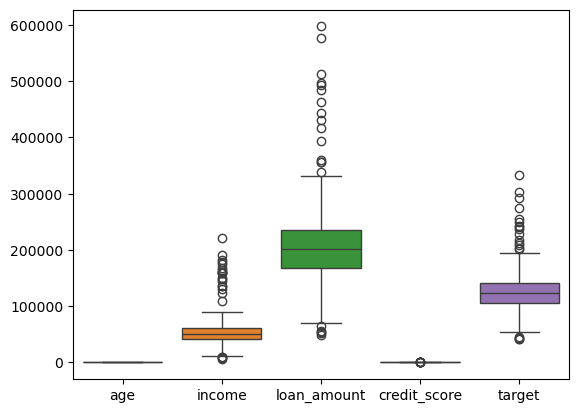

In [9]:
#check for outliers 
sns.boxplot(data=data)
plt.show()

In [14]:
# select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# handle outliers using IQR method
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# remove outliers
data = numeric_data[
    ~((numeric_data < lower_bound) | (numeric_data > upper_bound)).any(axis=1)
]

print(data_no_outliers)

     age        income    loan_amount  credit_score         target
0     56  25903.305196  286348.192562    789.476075  158793.631698
1     69  53051.954538  180018.190719    596.334039  115596.093965
2     46  38654.738821  211234.236288    611.531000  127231.057638
3     32  28666.194356  246629.541594    710.171152  145102.187078
4     60  40301.406736  129081.713353    622.900855  110623.128404
..   ...           ...            ...           ...            ...
994   63  48185.777771  188456.681308    718.447088  126510.447975
996   64  36687.617333  133069.710014    730.751324   65076.404995
997   62  43438.125495  234645.931152    747.044458  126006.462108
998   35  60835.720367  169706.958962    628.847359  118101.789665
999   55  44407.502719  285968.895310    467.780404  177122.529660

[865 rows x 5 columns]


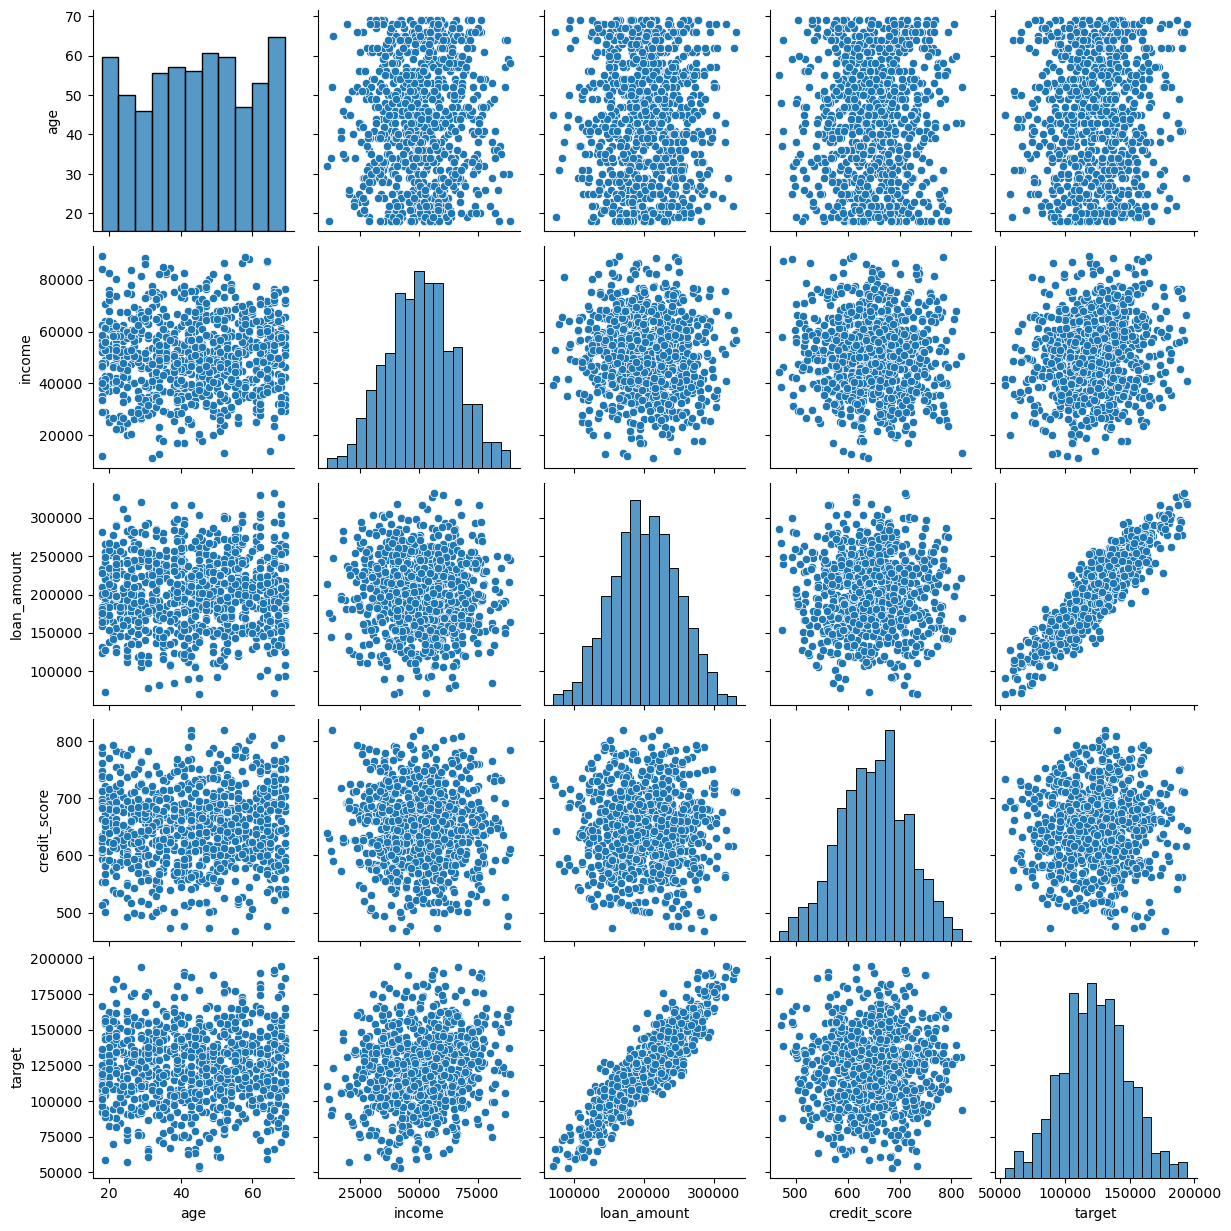

In [15]:
#visualize the data
sns.pairplot(data)
plt.show()

<Axes: >

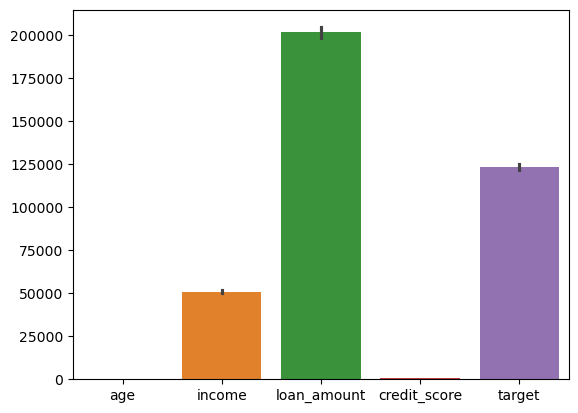

In [16]:
sns.barplot(data)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# train test split
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train KNN regressor
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

# predictions
y_pred = knn.predict(X_test_scaled)

# evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 147264854.43611962
R2 Score: 0.8100571597530827


In [20]:
#euclidean distance
from sklearn.metrics import pairwise_distances
distances = pairwise_distances(X_test_scaled, X_train_scaled, metric='euclidean')
print(distances)

[[2.88835077 2.53437756 2.23267437 ... 3.58604695 2.51085597 1.26975114]
 [1.52631896 1.19228593 2.35913301 ... 2.93726106 1.75206587 1.98577252]
 [0.93188762 1.64134722 1.37375534 ... 1.85052758 1.94273662 2.25620488]
 ...
 [1.66335905 1.71542814 2.49141035 ... 3.56246927 2.24301669 2.20495474]
 [2.94717108 1.85164427 3.15961926 ... 2.78163835 3.98986285 2.88784041]
 [1.43624115 0.62019185 2.47775272 ... 2.0550306  1.89335876 2.35781315]]


In [21]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': [3, 5, 7, 9]}
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)


Best parameters: {'n_neighbors': 9}


In [22]:
# different hyperparameter tuning 
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {'n_neighbors': randint(1, 20)}
random_search = RandomizedSearchCV(KNeighborsRegressor(), param_distributions=param_dist, n_iter=10, cv=5)
random_search.fit(X_train_scaled, y_train)
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)

Best parameters from RandomizedSearchCV: {'n_neighbors': 9}
